In [ ]:
pip install pandas seaborn sklearn -q

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [10]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán khả năng đơn hàng bị giao trễ hạn

## Khởi tạo SparkSession

In [11]:
spark = SparkSession.builder \
    .appName("olist_classification") \
    .getOrCreate()

## Load data từ Hadoop

In [12]:
hdfs_path = "hdfs://localhost:9000/bigdata/"

orders = spark.read.csv(hdfs_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
order_items = spark.read.csv(hdfs_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
products = spark.read.csv(hdfs_path + "olist_products_dataset.csv", header=True, inferSchema=True)
customers = spark.read.csv(hdfs_path + "olist_customers_dataset.csv", header=True, inferSchema=True)

## Tạo biến mục tiêu

In [13]:
orders_delivered = (
    orders
    .filter(col("order_status") == "delivered")
    .filter(col("order_delivered_customer_date").isNotNull())
    .filter(col("order_estimated_delivery_date").isNotNull())
)

orders_delivered = orders_delivered.withColumn(
    "label",
    when(
        col("order_delivered_customer_date")
        >
        col("order_estimated_delivery_date"),
        1
    ).otherwise(0)
)

## Aggregate Order Items & Product Features

In [14]:
items_agg = (
    order_items
    .groupBy("order_id")
    .agg(
        count("*").alias("num_items"),
        sum("price").alias("total_price"),
        sum("freight_value").alias("total_freight")
    )
)

products_agg = (
    order_items
    .join(products, "product_id")
    .groupBy("order_id")
    .agg(
        avg("product_weight_g").alias("avg_weight"),
        avg("product_length_cm").alias("avg_length"),
        avg("product_height_cm").alias("avg_height"),
        avg("product_width_cm").alias("avg_width")
    )
)

In [15]:
df = (
    orders_delivered
    .join(customers, "customer_id")
    .join(items_agg, "order_id")
    .join(products_agg, "order_id")
)

## Feture Engineering

In [16]:
df = (
    df
    .withColumn(
        "estimated_days",
        datediff(
            col("order_estimated_delivery_date"),
            col("order_purchase_timestamp")
        )
    )
    .withColumn(
        "processing_days",
        datediff(
            col("order_delivered_carrier_date"),
            col("order_purchase_timestamp")
        )
    )
    .withColumn(
        "actual_shipping_days",
        datediff(
            col("order_delivered_customer_date"),
            col("order_delivered_carrier_date")
        )
    )
    .withColumn(
        "purchase_month",
        month("order_purchase_timestamp")
    )
    .withColumn(
        "purchase_weekday",
        dayofweek("order_purchase_timestamp")
    )
    .withColumn(
        "freight_ratio",
        col("total_freight") /
        (col("total_price") + lit(0.01))
    )
    .withColumn(
        "product_volume",
        col("avg_length")
        * col("avg_height")
        * col("avg_width")
    )
)

## Tiền xử lý dữ liệu

In [17]:
df = df.na.fill(0)

In [18]:
categorical_cols = [
    "customer_state"
]

numeric_cols = [
    "num_items",
    "total_price",
    "total_freight",
    "avg_weight",
    "product_volume",
    "estimated_days",
    "processing_days",
    "actual_shipping_days",
    "purchase_month",
    "purchase_weekday",
    "freight_ratio"
]

In [19]:
label_counts = (
    df.groupBy("label")
      .count()
      .collect()
)

count_0 = [x["count"] for x in label_counts if x["label"] == 0][0]
count_1 = [x["count"] for x in label_counts if x["label"] == 1][0]

total = count_0 + count_1

weight_0 = total / (2.0 * count_0)
weight_1 = total / (2.0 * count_1)

df = df.withColumn(
    "classWeight",
    when(col("label") == 1, weight_1)
    .otherwise(weight_0)
)

In [20]:
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_vec"
    )
    for c in categorical_cols
]

In [21]:
feature_cols = (
    [f"{c}_vec" for c in categorical_cols]
    + numeric_cols
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

## Chia tập Train/Test

In [22]:
train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [23]:
# Cache dữ liệu để tránh Spark recompute nhiều lần
train_df.cache()
test_df.cache()

# Materialize cache
train_df.count()
test_df.count()

19308

In [24]:
gbt = GBTClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight",
    maxIter=50,
    maxDepth=6,
    stepSize=0.1,
    seed=42
)

## Train mô hình

In [25]:
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [26]:
configs = [
    (4, 20),
    (5, 20),
    (6, 20),
    (5, 30)
]

In [27]:
for depth, iters in configs:

    gbt = GBTClassifier(
        labelCol="label",
        featuresCol="features",
        maxDepth=depth,
        maxIter=iters,
        weightCol="classWeight"
    )

    pipeline = Pipeline(
        stages=indexers + encoders + [assembler, gbt]
    )

    model = pipeline.fit(train_df)

    pred = model.transform(test_df)

    auc = auc_evaluator.evaluate(pred)

    print(depth, iters, auc)

4 20 0.9944026720228031
5 20 0.9969424217714665
6 20 0.998116885110588
5 30 0.9977253318786272


In [28]:
predictions = model.transform(test_df)

## Đánh giá mô hình

In [29]:


roc_auc = auc_evaluator.evaluate(predictions)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9977253318786272


In [30]:
pr_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderPR"
)

pr_auc = pr_evaluator.evaluate(predictions)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9763500008458162


In [31]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="accuracy"
).evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9677853739382639


In [32]:
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="f1"
).evaluate(predictions)

print("F1:", f1)

F1: 0.970097170030159


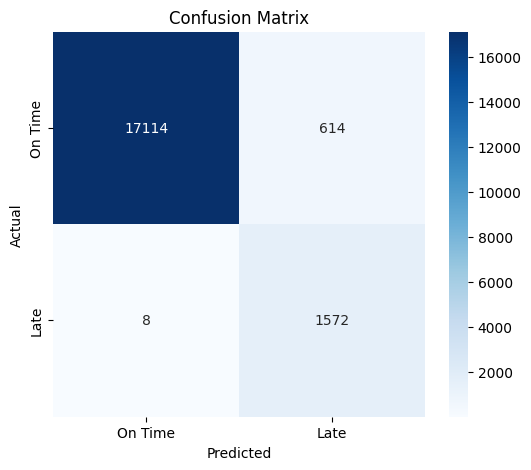

In [33]:
pred_pd = predictions.select(
    "label",
    "prediction"
).toPandas()

cm = confusion_matrix(
    pred_pd["label"],
    pred_pd["prediction"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On Time","Late"],
    yticklabels=["On Time","Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [34]:
best_model = model.bestModel

gbt_model = best_model.stages[-1]

print(gbt_model.featureImportances)

AttributeError: 'PipelineModel' object has no attribute 'bestModel'